In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from matplotlib import gridspec
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})
# from bumps.names import Parameter
# from bumps.fitters import fit

# from sasmodels.core import load_model
# from sasmodels.bumps_model import Model, Experiment

# import bumps
# import sasmodels

In [5]:
def read_DAT_file(name):
    with open(name) as pdbfile:
        q = []
        I = []
        dI = []
        start = 10000
        for i,line in enumerate(pdbfile):
            if 'q(A-1)' in line:
                start = i
            if i > start: 
                splitted_line = [line[0:20], line[23:50], line[50:]]
                q.append(splitted_line[0])
                I.append(splitted_line[1])
                dI.append(splitted_line[2])
        q = np.array([float(i) for i in q])
        I = np.array([float(i) for i in I])
        dI = np.array([float(i) for i in dI])
        data = np.hstack((q.reshape(-1,1), I.reshape(-1,1), dI.reshape(-1,1)))
    return data

def convert_data(data, model):
    model_x = model[:,0]
    model_y = model[:,1]
    index = np.linspace(0, len(model_x)-1, len(model_x)) 
    model_q_new = []
    model_I_new = []
    for i in range(len(data)):
        data_q = data[i,0]
        array = np.abs(model_x - data_q)
        array = np.hstack((array.reshape(-1,1), index.reshape(-1,1)))
        array = array[np.argsort(array[:, 0])]
        loc = int(array[0,1])
        model_q_new.append(model_x[loc])
        model_I_new.append(model_y[loc])
    q = np.array(model_q_new).reshape(-1,1)
    I = np.array(model_I_new).reshape(-1,1)
    new_model_data = np.hstack((q, I))
    return new_model_data






def normalize_scattering_curves(q, I1, I2, q_min, q_max):
    """
    Normalizes the second scattering curve to match the first within the q-range [q_min, q_max].

    Parameters:
        data (np.ndarray): 2D array with shape (N, 3), where
                           - column 0: q values,
                           - column 1: intensity of curve 1,
                           - column 2: intensity of curve 2
        q_min (float): lower bound of q-range for normalization
        q_max (float): upper bound of q-range for normalization

    Returns:
        np.ndarray: New array with same shape as input, with column 2 normalized
    """
    # Mask to select points within the given q-range
    mask = (q >= q_min) & (q <= q_max)
    if not np.any(mask):
        raise ValueError("No data points found within the specified q-range.")
    # Calculate normalization factor
    scale_factor = np.mean(I1[mask]) / np.mean(I2[mask])
    # Apply normalization
    I2_normalized = I2 * scale_factor
    # Return the combined array
    return I2_normalized


def calculate_structure_factor(data0, data2, q_min, q_max, plot):
    new_data_2 = convert_data(data0, data2)
    fig, ax = plt.subplots(figsize=(7,7))
    normalized_data = normalize_scattering_curves(new_data_2[:,0], new_data_2[:,1], data0[:,1], q_min, q_max)
    plt.scatter(data0[:,0], normalized_data, color = 'blue', label = 'data0')
    plt.scatter(new_data_2[:,0], new_data_2[:,1], color = 'red', label = 'data2')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel('Intensity (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
    if plot == False:
        plt.close()
    structure_factor = new_data_2[:,1]/((normalized_data))
    structure_factor = np.hstack((new_data_2[:,0].reshape(-1,1), structure_factor.reshape(-1,1)))
    return structure_factor


## Load Structure Factor Data

In [42]:
sq_list = []

path = '../Data/Simulations/Bridge 20 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

path = '../Data/Simulations/Bridge 40 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

path = '../Data/Simulations/Bridge 80 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

(0.1, 10)

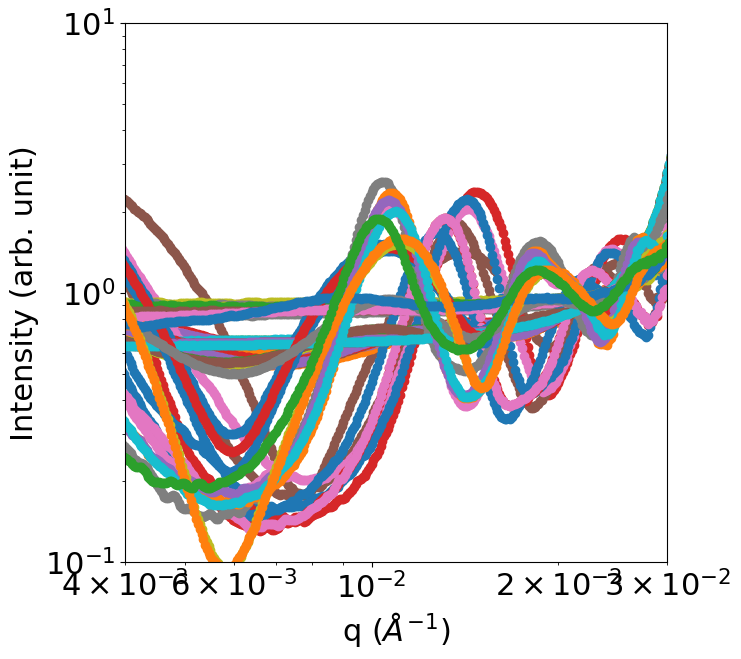

In [50]:
fig, ax = plt.subplots(figsize=(7,7))
for i in range(len(sq_list)):
    plt.scatter(sq_list[i][:,0], sq_list[i][:,1], label = '20 Brigde')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Intensity (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
plt.xlim([0.004, 0.03])
plt.ylim([0.1, 10])
#plt.savefig('../Figures/Brigde_length.png', dpi=600, bbox_inches="tight")